# 06 · Live Demo  🌿
**Run under pressure:** (1) run the two preamble cells, (2) load the predictor, (3) set `DEMO_IMAGES` (a folder or list of paths) and run. Loads only saved checkpoints — no training state.

> Needs trained checkpoints on this runtime (same session as training, or a Drive-mounted `checkpoint_dir`).

In [1]:
# === Preamble 1/2: environment & GPU report ===
# This is a REMOTE Colab kernel — it cannot see your local files.
import sys
print('Python:', sys.version.split()[0])
try:
    import torch
    print('PyTorch:', torch.__version__, '| CUDA:', torch.cuda.is_available())
    if torch.cuda.is_available():
        print('GPU:', torch.cuda.get_device_name(0))
        print('bfloat16 supported:', torch.cuda.is_bf16_supported())
    else:
        print('No GPU — Runtime > Change runtime type > A100 (or L4).')
except ImportError:
    print('torch installs in the next cell.')

Python: 3.12.13
PyTorch: 2.11.0+cu128 | CUDA: True
GPU: NVIDIA A100-SXM4-40GB
bfloat16 supported: True


In [2]:
# === Preamble 2/2: clone-or-pull + install (+ optional autoreload) ===
import os, subprocess, sys

REPO_URL = "https://github.com/Kidhurshan/plant-leaf-classifier.git"  # <-- EDIT to your repo
REPO_DIR = "/content/plant-leaf-classifier"
# Private repo? use https://<TOKEN>@github.com/Kidhurshan/plant-leaf-classifier.git

if not os.path.isdir(REPO_DIR):
    print('Cloning', REPO_URL)
    subprocess.run(['git', 'clone', REPO_URL, REPO_DIR], check=True)
os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r',
                'requirements.txt'], check=True)

# Hot-reload src/ after a `git pull` (optional convenience; never fatal).
try:
    from IPython import get_ipython
    _ip = get_ipython()
    _ip.run_line_magic('load_ext', 'autoreload')
    _ip.run_line_magic('autoreload', '2')
    print('autoreload enabled.')
except Exception as _e:
    print('autoreload not enabled (non-fatal):', repr(_e))

from src.utils import sync_repo, gpu_report
sync_repo()   # git pull + print the commit hash these results are traceable to
gpu_report()

autoreload not enabled (non-fatal): ModuleNotFoundError("No module named 'imp'")
Syncing repository (git pull)...
From https://github.com/Kidhurshan/plant-leaf-classifier
   4f1c264..b3bfe06  main       -> origin/main
Updating 4f1c264..b3bfe06
Fast-forward
 notebooks/05_compare_and_ensemble.ipynb |  19 +++
 notebooks/06_live_demo.ipynb            | 258 ++++++++++++++++++++++++++++----
 src/inference.py                        |  71 +++++----
 3 files changed, 290 insertions(+), 58 deletions(-)
Now running code at commit: b3bfe06 [DIRTY WORKING TREE]

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!! The pull brought NEW CODE into this runtime.
!! %autoreload CANNOT reload changed classes/dataclasses.
!! -> RESTART THE KERNEL now, then run the notebook from the top.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
ENVIRONMENT
  Python        : 3.12.13
  PyTorch       : 2.11.0+cu128
  CUDA available: True
  GPU           : NVIDIA A100-SXM4-40GB
  

{'python': '3.12.13',
 'torch': '2.11.0+cu128',
 'cuda_available': True,
 'gpu': 'NVIDIA A100-SXM4-40GB',
 'vram_gb': 39.5,
 'cuda_version': '12.8',
 'bf16_supported': True}

## (Optional) mount Drive if checkpoints live there

In [3]:
# from google.colab import drive; drive.mount('/content/drive')
CKPT_DIR = None  # e.g. '/content/drive/MyDrive/task4_ckpts', else default

## Load the predictor (best single model or the ensemble)

In [4]:
from src.config import load_config
from src.utils import use_drive_paths
from src.inference import build_predictor
import torch

cfg = load_config('configs/default.yaml')
use_drive_paths(cfg)          # mounts Drive if needed + points at Drive checkpoints

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 'cbam_convnext' = your proposed model (100% test). 'ensemble' = all three.
WHICH = 'cbam_convnext'

try:
    predictor = build_predictor(cfg, device, which=WHICH)
    print('Loaded:', list(predictor.models), '| classes:', predictor.class_names)
except FileNotFoundError as e:
    print('No checkpoints found:\n', e)


[drive] cache_dir      -> /content/drive/MyDrive/task4_egypli/cache
[drive] checkpoint_dir -> /content/drive/MyDrive/task4_egypli/checkpoints


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


10:49:34 | INFO    | CBAM attached to ConvNeXt stages [2, 3] (channels [384, 768]).
10:49:34 | INFO    | Built 'cbam_convnext' (backbone=convnext_tiny.fb_in22k_ft_in1k, cbam=True): 27.9M params (27.9M trainable).
10:49:34 | INFO    | Loaded 'cbam_convnext' weights from /content/drive/MyDrive/task4_egypli/checkpoints/cbam_convnext_best.pt (val macro-F1=1.0000).
10:49:34 | INFO    | Predictor ready: models=['cbam_convnext'], weights={'cbam_convnext': 1.0}
Loaded: ['cbam_convnext'] | classes: ['apple', 'berry', 'fig', 'guava', 'orange', 'palm', 'persimmon', 'tomato']


## Predict on your images
Set `DEMO_IMAGES` to a folder or a list of image paths.

/content/plant-leaf-classifier/src/inference.py:91: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  return torch.from_numpy(np.transpose(a, (2, 0, 1)))  # CHW uint8


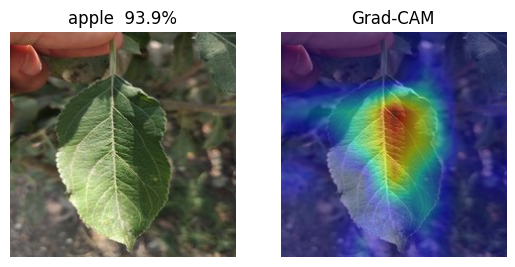

  top-3: apple 93.9%, palm 3.5%, berry 1.5%


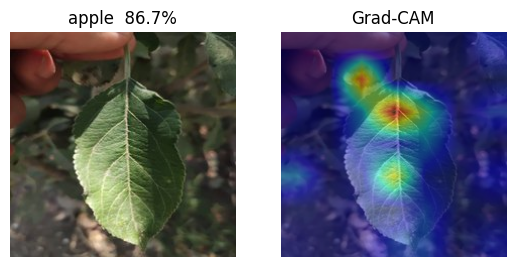

  top-3: apple 86.7%, palm 8.5%, berry 2.9%


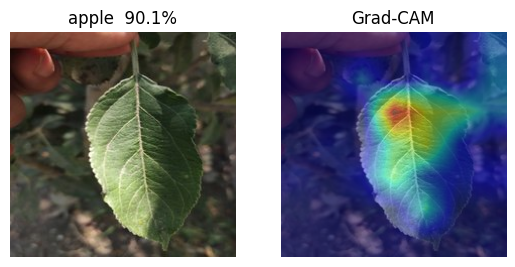

  top-3: apple 90.1%, palm 6.3%, berry 2.4%


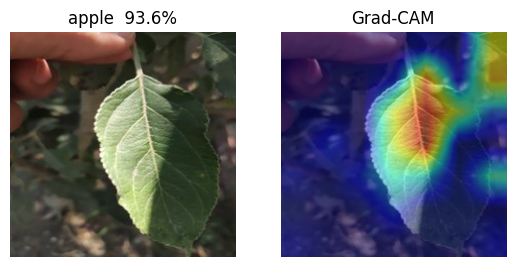

  top-3: apple 93.6%, palm 3.5%, berry 1.5%


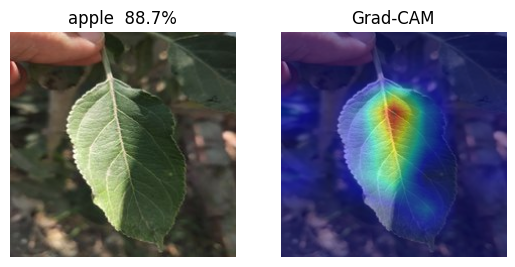

  top-3: apple 88.7%, palm 8.7%, berry 1.6%


In [5]:
import matplotlib.pyplot as plt
DEMO_IMAGES = ['/content/plant-leaf-classifier/data']   # folder or list of image paths

def show(results):
    for r in results:
        cols = 2 if 'gradcam' in r else 1
        fig, ax = plt.subplots(1, cols, figsize=(3.2*cols, 3.2))
        ax = [ax] if cols == 1 else ax
        ax[0].imshow(r['image']); ax[0].axis('off')
        ax[0].set_title(f"{r['pred']}  {r['confidence']*100:.1f}%")
        if 'gradcam' in r:
            ax[1].imshow(r['gradcam']); ax[1].axis('off'); ax[1].set_title('Grad-CAM')
        plt.show()
        print('  top-3:', ', '.join(f'{n} {p*100:.1f}%' for n, p in r['topk']))

results = predictor.predict(DEMO_IMAGES, top_k=3, with_gradcam=True, max_images=5)
show(results)


## Evaluator mode — 5 random images

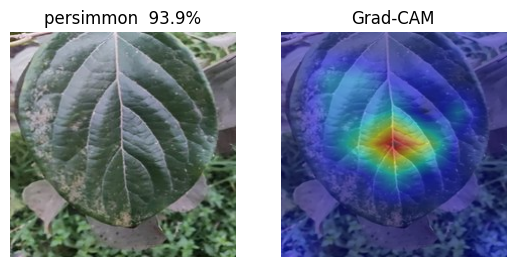

  top-3: persimmon 93.9%, berry 5.2%, palm 0.3%


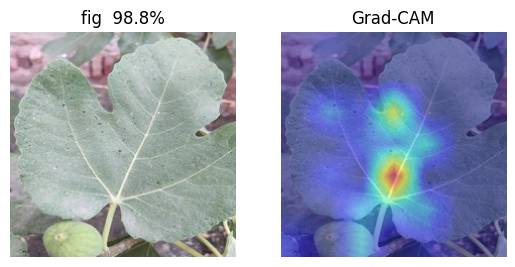

  top-3: fig 98.8%, berry 0.8%, apple 0.2%


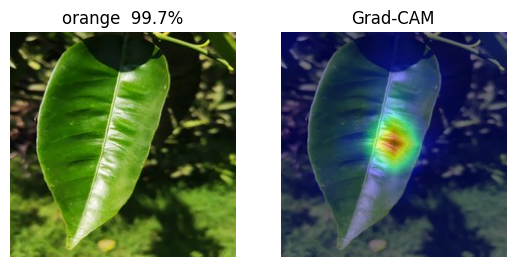

  top-3: orange 99.7%, guava 0.2%, palm 0.0%


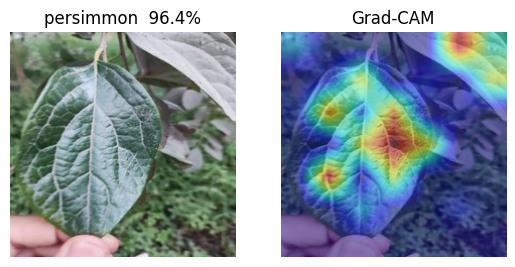

  top-3: persimmon 96.4%, palm 2.8%, berry 0.5%


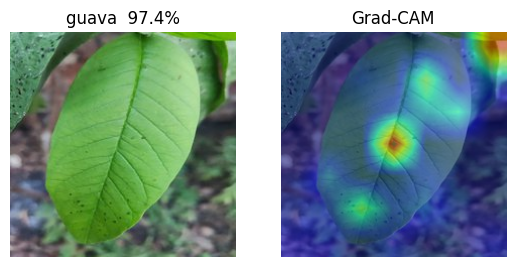

  top-3: guava 97.4%, orange 1.5%, persimmon 0.6%


In [6]:
import random
from src.inference import gather_image_paths
pool = gather_image_paths([cfg.paths.data_dir])
if pool:
    show(predictor.predict(random.sample(pool, min(5, len(pool))),
                           top_k=3, with_gradcam=True))
else:
    print('No images under', cfg.paths.data_dir, '— point DEMO_IMAGES at real files.')

---
### ⚠️ When finished: disconnect and DELETE the runtime
`Runtime > Disconnect and delete runtime`. Colab compute units are consumed the whole time a runtime is connected.